# Importing Libraries

In [ ]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Data Loading and Audit


In [ ]:
df = pd.read_csv("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
print(df.head())

print("\n\n----------------------------------------------------------\n\n")
print(f"No.of Rows: {df.shape[0]}")
print(f"No.of columns: {df.shape[1]}")
print("\n\n----------------------------------------------------------\n\n")

print("\nColumn Names:")
print(df.columns.tolist())


print("\n\n----------------------------------------------------------\n\n")

print("Missing Values:")
print(df.isnull().sum().sum())

print("\nMissing Values per feature:")
print(df.isnull().sum())

print("\n\n----------------------------------------------------------\n\n")

print("Target Distribution:")
print(df["Diabetes_binary"].value_counts())

print("\n\n----------------------------------------------------------\n\n")

print("Dataset Information:")
df.info()


   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  \
0                   0.0           0.0     0.0      1.0                0.0   
1                   0.0           1.0     0.0      0.0                0.0   
2                   0.0           0.0     1.0      0.0                0.0   
3                   0.0           1.0     1.0      1.0                0.0   
4                   0.0           1.0     1.0      1.0                0.0   

   AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  \
0            1.0     

# Exploratory Data Analysis(EDA)

In [9]:
def get_df():
    df = pd.read_csv("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
    return df

def rm_empty_rows(df):
    df = df.copy()
    df = df.dropna()
    return df

def seperate_target(df):
    df = df.copy()
    cols = df.columns
    cols = list(cols)
    cols.remove("Diabetes_binary")
    target = df.drop(cols,axis=1,inplace=False)
    df.drop('Diabetes_binary', axis=1, inplace=True)
    return (target, df)


def standardization(df, cols):
    df = df.copy()
    scaler = sk.preprocessing.StandardScaler()
    for col in cols:
        df[col] = scaler.fit_transform(df[[col]])

    return df


def normalization(df, cols):
    df = df.copy()
    scaler = sk.preprocessing.MinMaxScaler()
    for col in cols:
        df[col] = scaler.fit_transform(df[[col]])

    return df

def get_split(target, df, test_size):
    df = df.copy()
    x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(df,target,test_size=test_size,random_state=42)
    return (x_train, x_test, y_train, y_test)

    
def get_regression_scores(y_test,y_pred):
    r2 = sk.metrics.r2_score(y_test, y_pred)
    rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred))
    mae = sk.metrics.mean_absolute_error(y_test, y_pred)
    return (r2, rmse, mae)
    

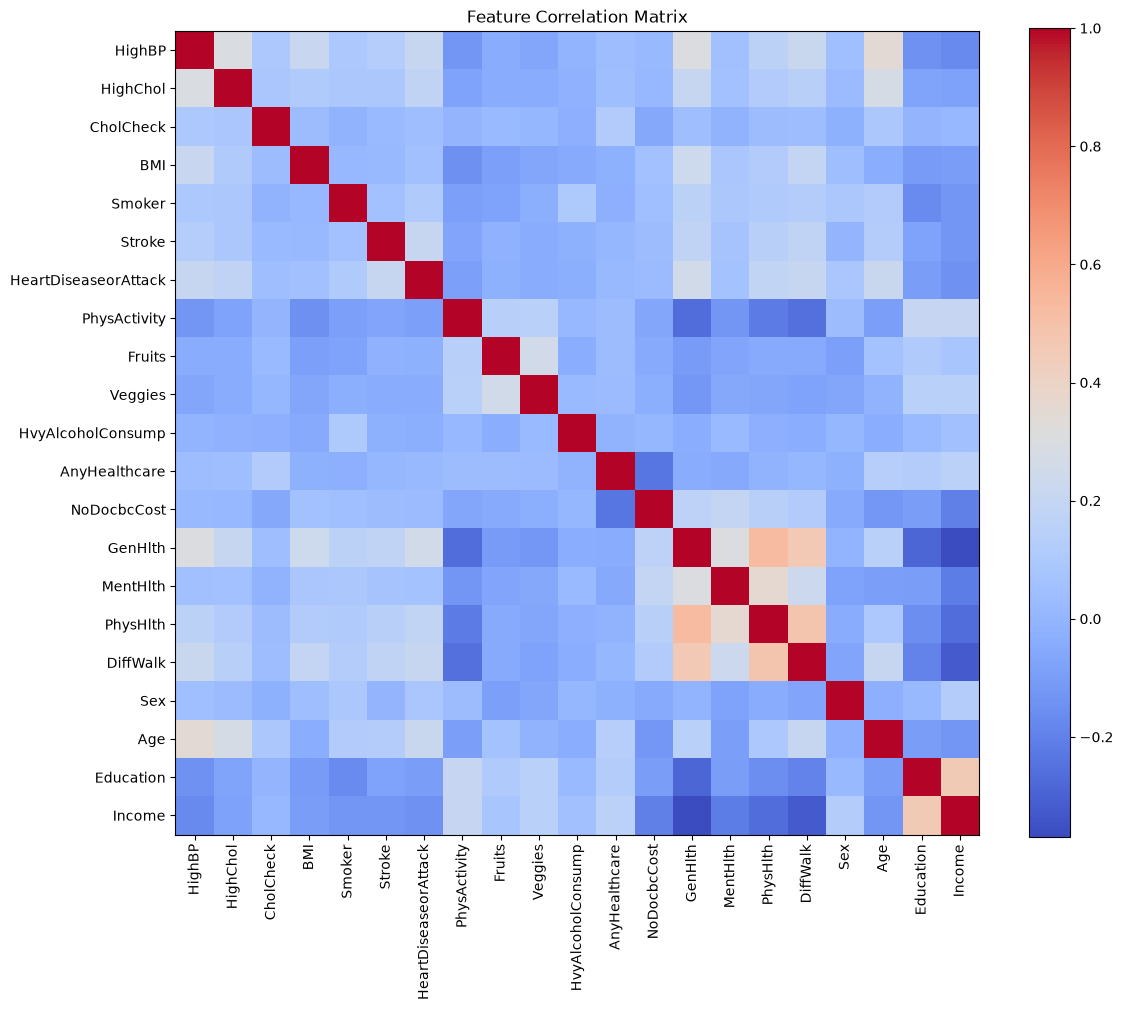

In [61]:
# Feature engineering


df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)

corr = df.corr()
plt.figure(figsize=(12, 10))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

def remove_highly_correlated_variables(df, threshold):
    df = df.copy()
    corr = df.corr()
    to_drop = set()
    correlation_threshold = threshold
    print("\n\n---------------------------------\n\n")
    print(f"Highly correlated features (correlation above: {correlation_threshold}):")

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            value = corr.iloc[i, j]
            if abs(value) > correlation_threshold:
                col1 = corr.columns[i]
                col2 = corr.columns[j]

                print(col1, "<->", col2, ":", value)

                to_drop.add(col1)
            
    #print(f"Removed features: {to_drop}")
    #print("\n\n---------------------------------\n\n")

    df.drop(columns=list(to_drop), inplace=True)
    
    return df



def apply_pca(x_train, x_test, variance):

    scaler = sk.preprocessing.StandardScaler()
    scaler.fit(x_train)
    pca = sk.decomposition.PCA(n_components=variance)
    x_train_scaled = scaler.transform(x_train)
    pca.fit(x_train_scaled)

    x_train_scaled = scaler.transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    x_train_pca = pca.transform(x_train_scaled)
    x_test_pca = pca.transform(x_test_scaled)
    """
    print("\n\n---------------------------------------\n\n")
    print("Original features:", x_train.shape[1])
    print("PCA features:", x_train_pca.shape[1])
    print("Explained variance:", pca.explained_variance_ratio_)
    print("Total variance retained:", pca.explained_variance_ratio_.sum())
    print("\n\n---------------------------------------\n\n")
    """

    return x_train_pca, x_test_pca, scaler, pca

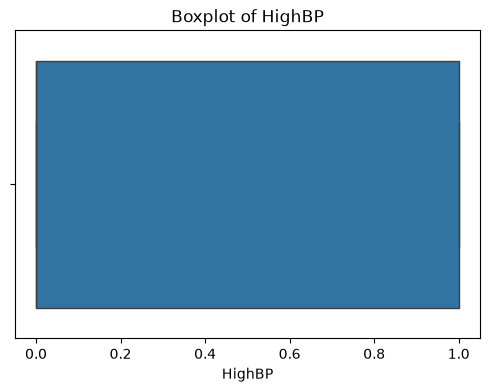

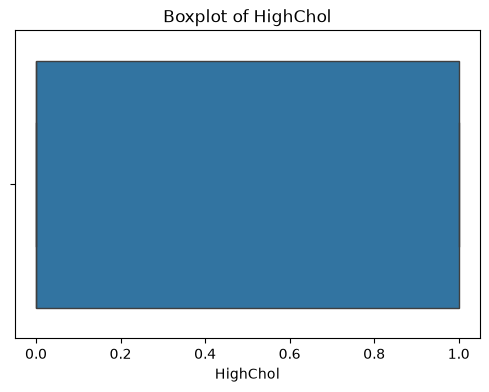

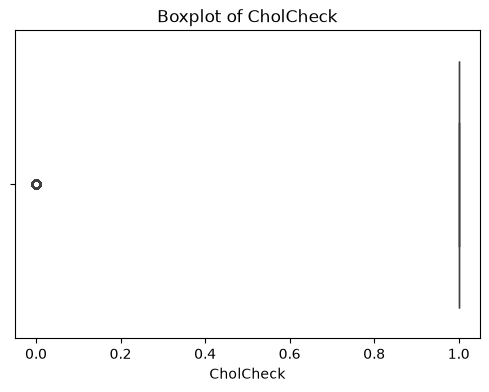

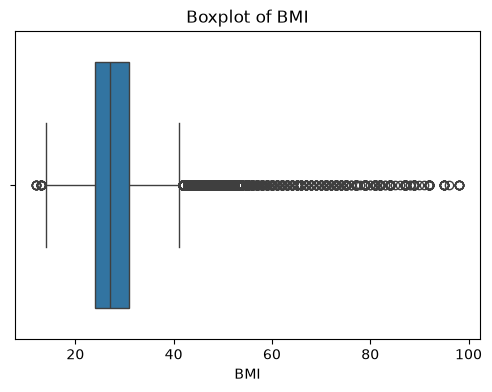

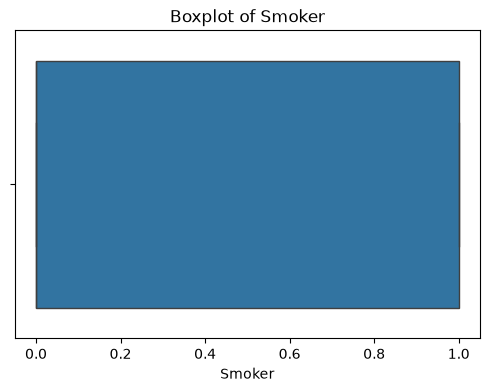

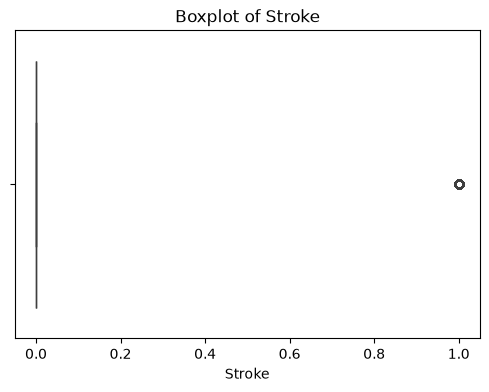

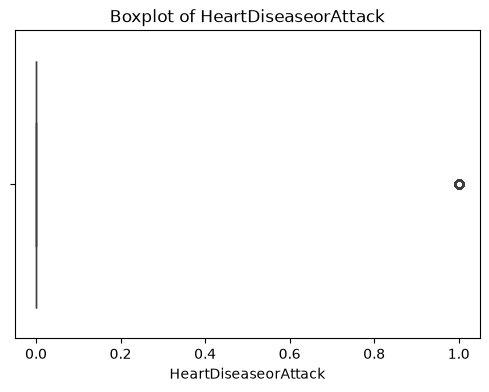

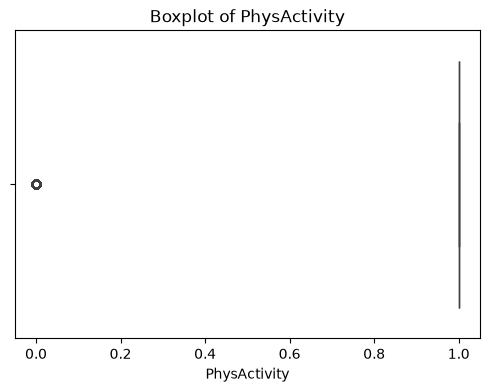

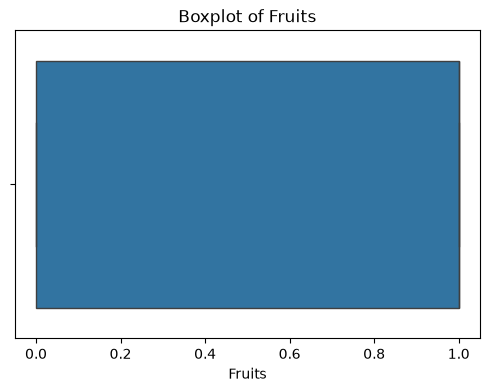

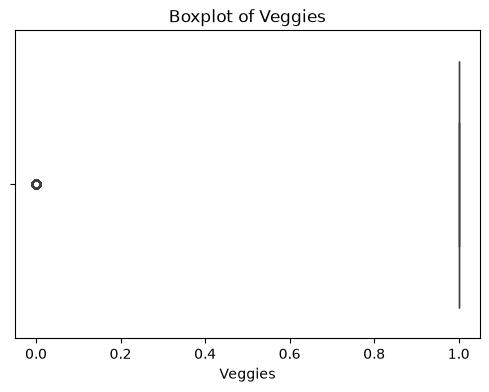

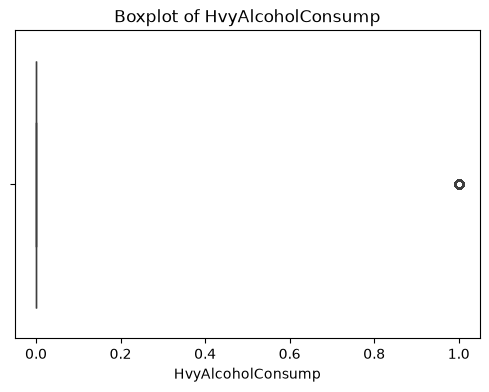

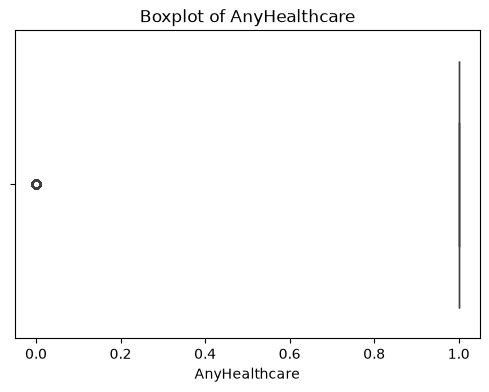

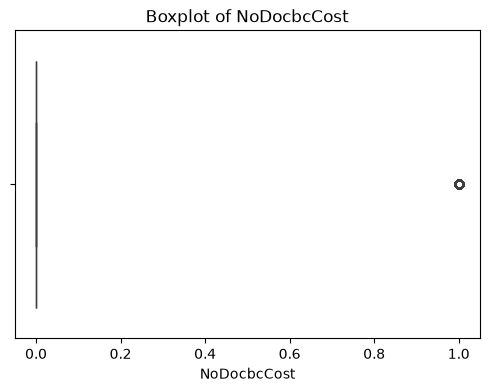

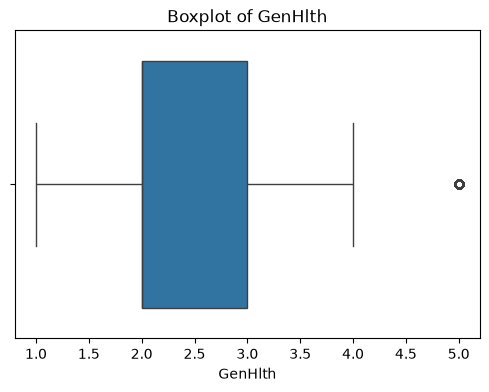

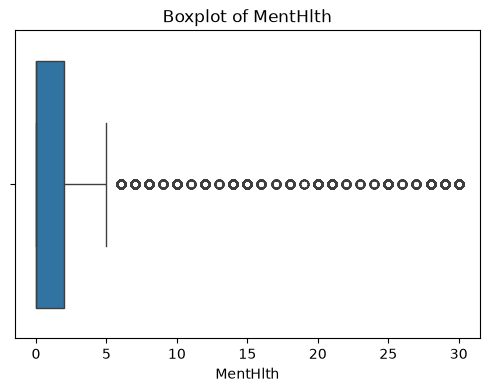

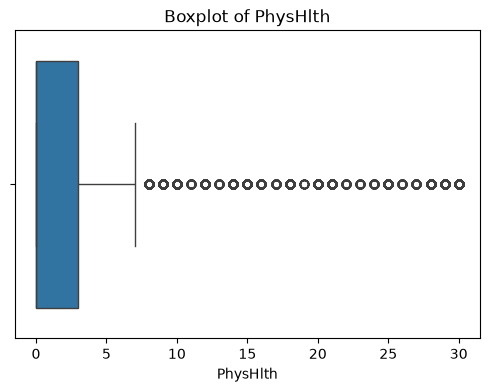

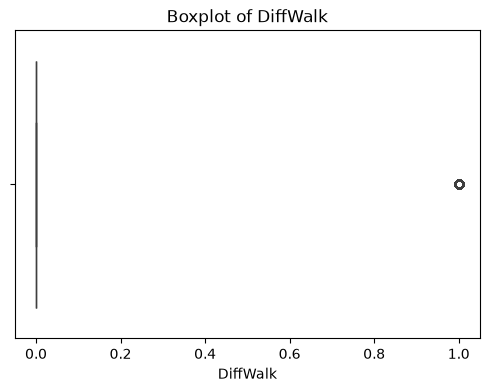

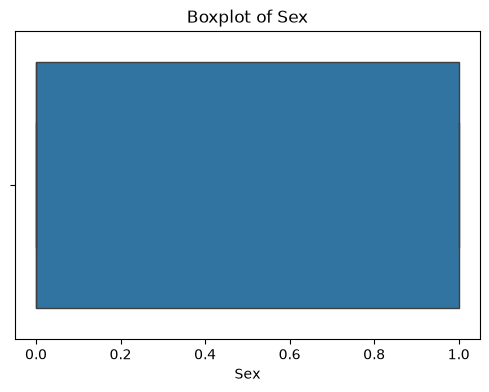

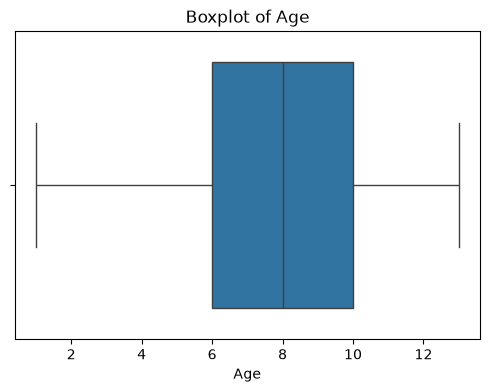

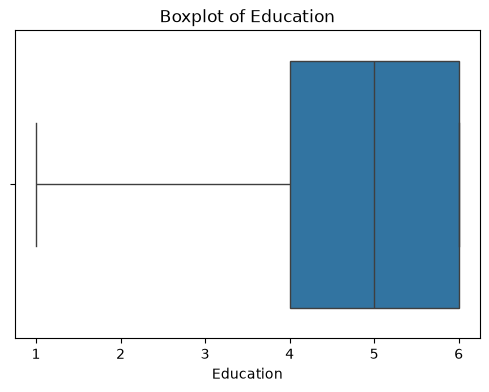

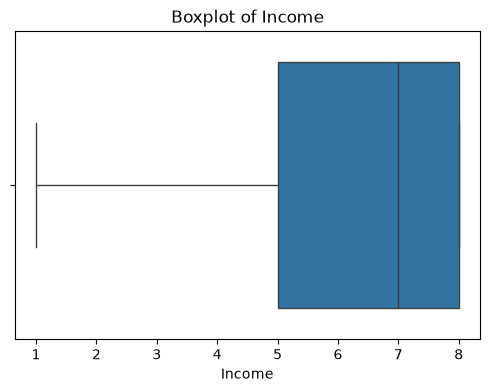

In [62]:
# Handling outliers

df = get_df()
target, df = seperate_target(df)
for col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


def remove_outliers(df,columns):
    df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        removed = df[
            (df[col] > upper) |
            (df[col] < lower)
        ]

        


        #print("\n\n--------------------------\n\n")
        #print(f"Removed outliers in {col}: ")
        #print("Shape of removed values: ", removed.shape)
        #print(removed.head())
        #print("\n\n--------------------------\n\n")


        df = df[
            (df[col] >= lower) &
            (df[col] <= upper)
        ]
    return df

def winsorize_outliers(df, columns):
    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = (
            (df[col] < lower) |
            (df[col] > upper)
        )

        #print(f"\n{col}")
        #print("Outliers:", outliers.sum())

        # Cap values
        df[col] = df[col].clip(
            lower=lower,
            upper=upper
        )

    return df

def replace_outliers_with_mean(df, columns):
    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = (
            (df[col] < lower) |
            (df[col] > upper)
        )

        #print(f"\n{col}")
        #print("Outliers:", outliers.sum())

        # Calculate mean excluding outliers
        mean = df.loc[~outliers, col].mean()

        # Replace outliers
        df.loc[outliers, col] = mean

    return df


In [63]:

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
df = standardization(df, df.columns)

print(df.head())
for col in df.columns:
    print(f"{col}")
    print(df[col].unique())

     HighBP  HighChol  CholCheck       BMI    Smoker    Stroke  \
0  1.153688  1.165254   0.196922  1.757936  1.120927 -0.205637   
1 -0.866785 -0.858182  -5.078164 -0.511806  1.120927 -0.205637   
2  1.153688  1.165254   0.196922 -0.057858 -0.892119 -0.205637   
3  1.153688 -0.858182   0.196922 -0.209174 -0.892119 -0.205637   
4  1.153688  1.165254   0.196922 -0.663122 -0.892119 -0.205637   

   HeartDiseaseorAttack  PhysActivity    Fruits   Veggies  ...  AnyHealthcare  \
0             -0.322458     -1.762814 -1.316872  0.482087  ...       0.226863   
1             -0.322458      0.567275 -1.316872 -2.074316  ...      -4.407954   
2             -0.322458     -1.762814  0.759375 -2.074316  ...       0.226863   
3             -0.322458      0.567275  0.759375  0.482087  ...       0.226863   
4             -0.322458      0.567275  0.759375  0.482087  ...       0.226863   

   NoDocbcCost   GenHlth  MentHlth  PhysHlth  DiffWalk       Sex       Age  \
0    -0.303173  2.329121  1.998592  1.

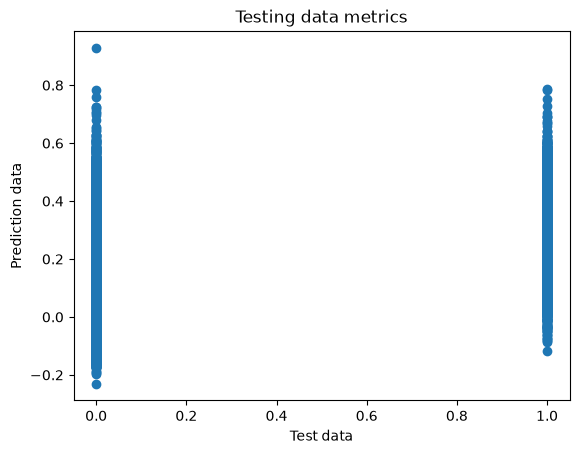

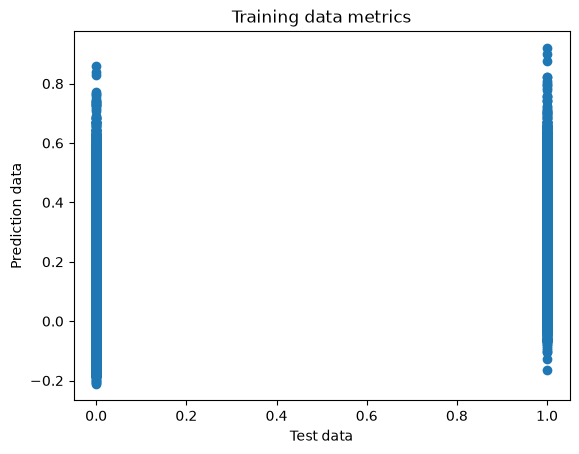



---------------------------------


Training data metrics: 
R2 score: 0.16162058006435076
RMSE score: 0.3174160344520745
MAE score: 0.21692273182248506


---------------------------------




---------------------------------


Testing data metrics: 
R2 score: 0.16269021365974257
RMSE score: 0.31551297282623975
MAE score: 0.21599714558586175


---------------------------------




---------------------------------


Training data metrics(with remove_outliers): 
R2 score: 0.09502494830517805
RMSE score: 0.24761634568291632
MAE score: 0.13576847580738974


---------------------------------




---------------------------------


Testing data metrics(with remove_outliers): 
R2 score: 0.09327536146150261
RMSE score: 0.25179454316908373
MAE score: 0.13802471937675165


---------------------------------




---------------------------------


Training data metrics(with replace_outliers_with_mean): 
R2 score: 0.13735746499022272
RMSE score: 0.321976363747538
MAE score: 0.2228671659977854




'\nmax_points = 100\nn_points = min(max_points, len(x_test))\n\n# Randomly select indices\nrandom_indices = np.random.choice(\n    len(x_test),\n    size=n_points,\n    replace=False\n)\n\nfor feature in x_test.columns:\n\n    plt.figure(figsize=(8, 5))\n\n    x_values = x_test[feature].iloc[random_indices]\n    actual = y_test.iloc[random_indices]\n    predicted = y_test_pred[random_indices]\n\n    plt.scatter(x_values, actual, label="Actual")\n    plt.scatter(x_values, predicted, label="Predicted")\n\n    plt.xlabel(feature)\n    plt.ylabel("Target")\n    plt.title(f"{feature}: Actual vs Predicted")\n\n    plt.legend()\n    plt.grid(True)\n    plt.show()\n\n'

In [64]:
# Linear regression

SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)

df = standardization(df, df.columns)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)

model_path = "../models/linear_regression.pkl"
if os.path.exists(model_path):
    model = joblib.load(model_path)
else:
    model = sk.linear_model.LinearRegression()
    model.fit(x_train,y_train)
    joblib.dump(model,model_path)

y_test_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)

plt.figure()
plt.scatter(y_test,y_test_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Testing data metrics")
plt.show()


plt.figure()
plt.scatter(y_train,y_train_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Training data metrics")
plt.show()


r2, rmse, mae = get_regression_scores(y_train,y_train_pred)
print("\n\n---------------------------------\n\n")
print(f"Training data metrics: ")
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")
print(f"MAE score: {mae}")
print("\n\n---------------------------------\n\n")


r2, rmse, mae = get_regression_scores(y_test,y_test_pred)
print("\n\n---------------------------------\n\n")
print(f"Testing data metrics: ")
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")
print(f"MAE score: {mae}")
print("\n\n---------------------------------\n\n")



def do_linear_regression(outlier_func):
    df = get_df()
    df = rm_empty_rows(df)
    columns = list(df.columns)
    columns.remove("Diabetes_binary")
    df = outlier_func(df,columns)
    target, df = seperate_target(df)
    x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)
    x_train_pca,x_test_pca,_,_ = apply_pca(x_train,x_test,0.9)

    model = sk.linear_model.LinearRegression()
    model.fit(x_train_pca,y_train)
    y_test_pred = model.predict(x_test_pca)
    y_train_pred = model.predict(x_train_pca)

    r2, rmse, mae = get_regression_scores(y_train,y_train_pred)
    print("\n\n---------------------------------\n\n")
    print(f"Training data metrics(with {outlier_func.__name__}): ")
    print(f"R2 score: {r2}")
    print(f"RMSE score: {rmse}")
    print(f"MAE score: {mae}")
    print("\n\n---------------------------------\n\n")


    r2, rmse, mae = get_regression_scores(y_test,y_test_pred)
    print("\n\n---------------------------------\n\n")
    print(f"Testing data metrics(with {outlier_func.__name__}): ")
    print(f"R2 score: {r2}")
    print(f"RMSE score: {rmse}")
    print(f"MAE score: {mae}")
    print("\n\n---------------------------------\n\n")


do_linear_regression(remove_outliers)
do_linear_regression(replace_outliers_with_mean)
do_linear_regression(winsorize_outliers)

"""
max_points = 100
n_points = min(max_points, len(x_test))

# Randomly select indices
random_indices = np.random.choice(
    len(x_test),
    size=n_points,
    replace=False
)

for feature in x_test.columns:

    plt.figure(figsize=(8, 5))

    x_values = x_test[feature].iloc[random_indices]
    actual = y_test.iloc[random_indices]
    predicted = y_test_pred[random_indices]

    plt.scatter(x_values, actual, label="Actual")
    plt.scatter(x_values, predicted, label="Predicted")

    plt.xlabel(feature)
    plt.ylabel("Target")
    plt.title(f"{feature}: Actual vs Predicted")

    plt.legend()
    plt.grid(True)
    plt.show()

"""


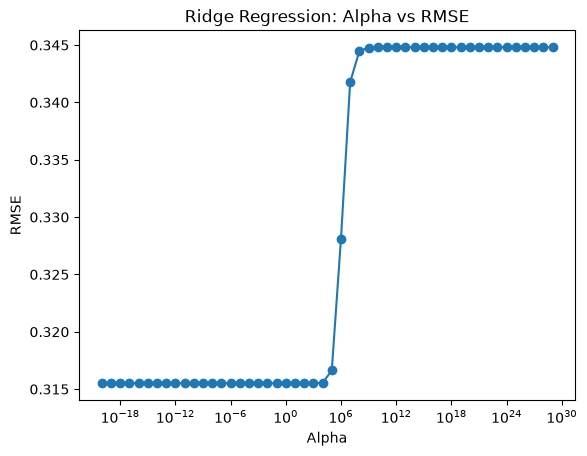

Least RMSE value: 0.3155129728262397
Coresponding learning rate: 1e-20


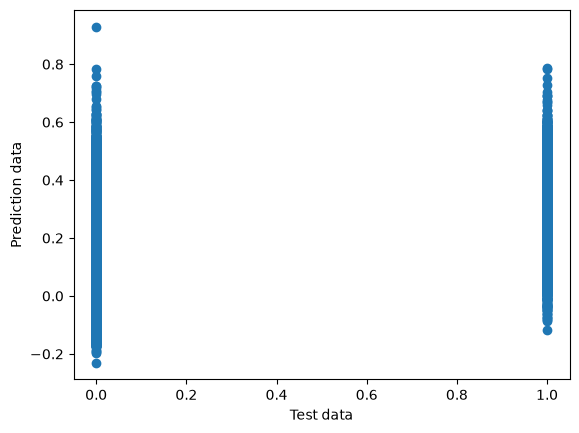

R2 score: 0.16269021365974268
RMSE score: 0.3155129728262397
MAE score: 0.21599714558586353


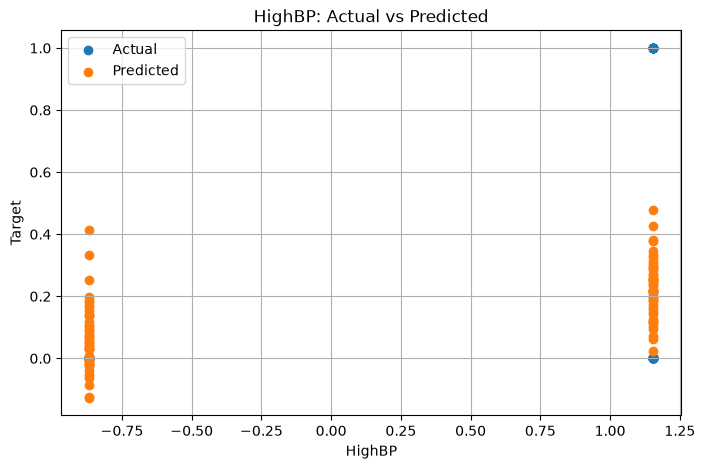

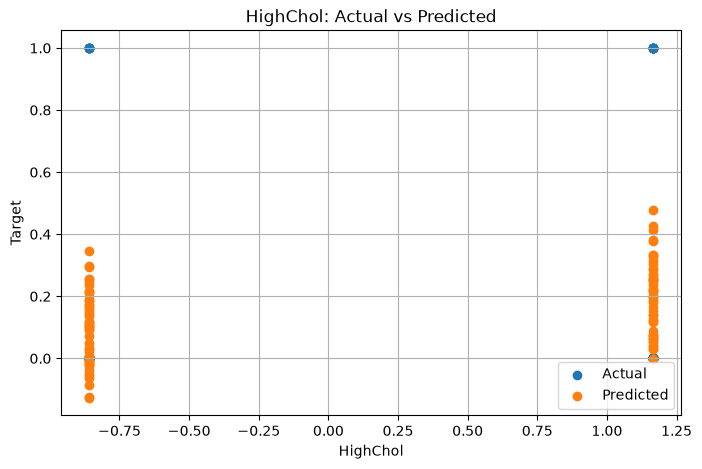

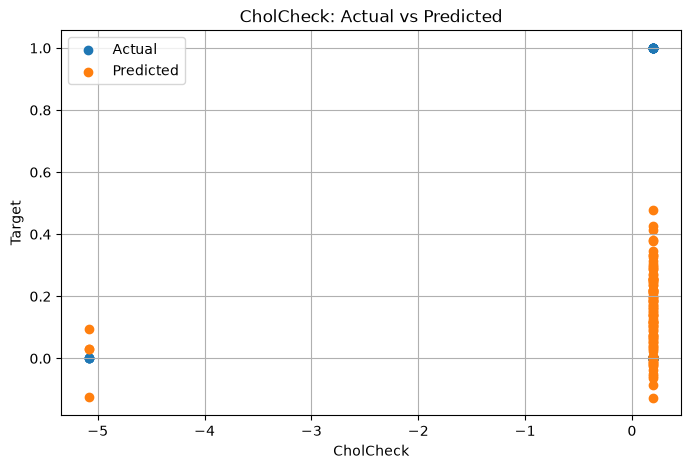

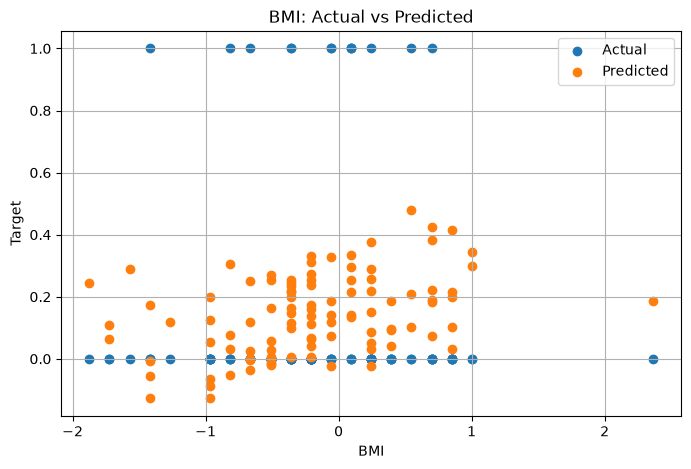

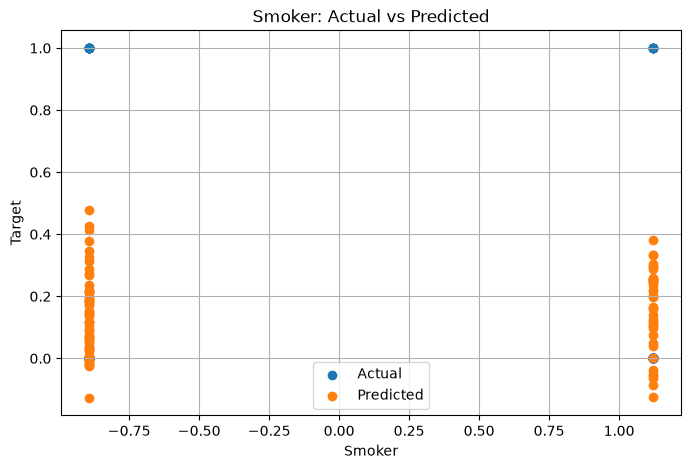

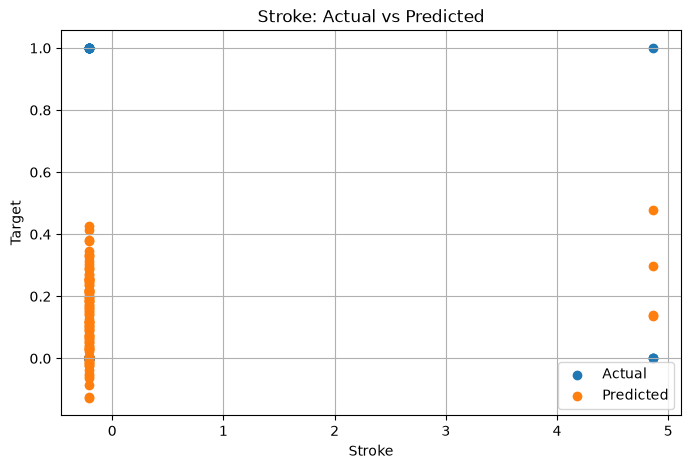

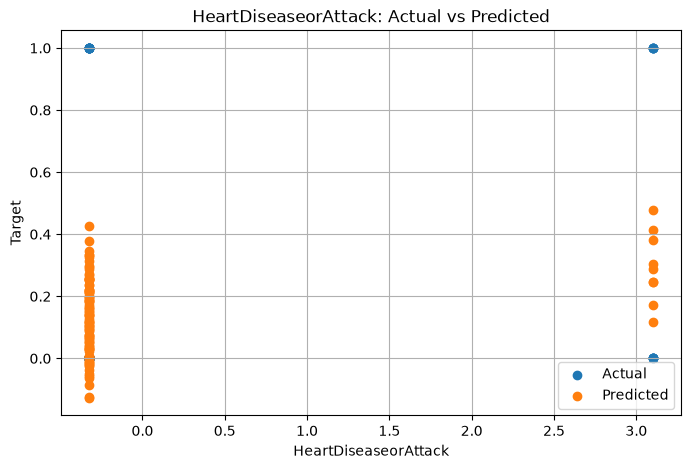

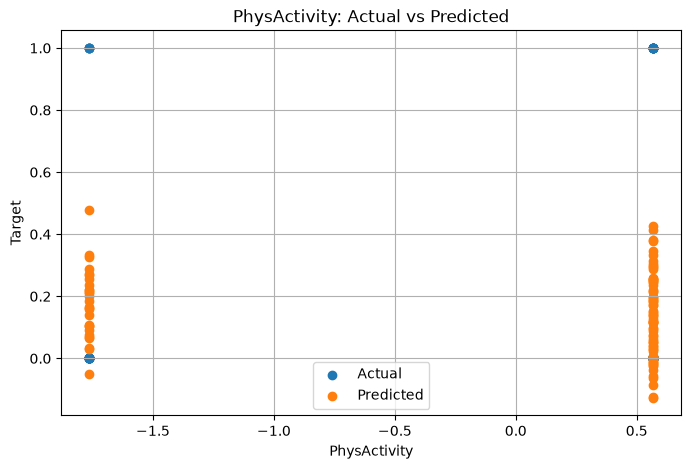

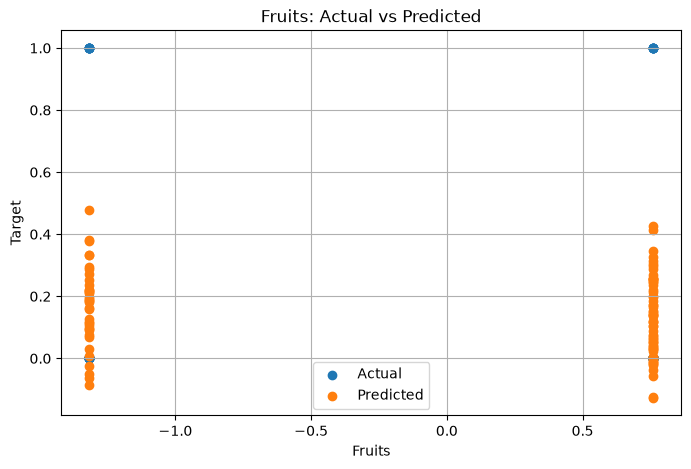

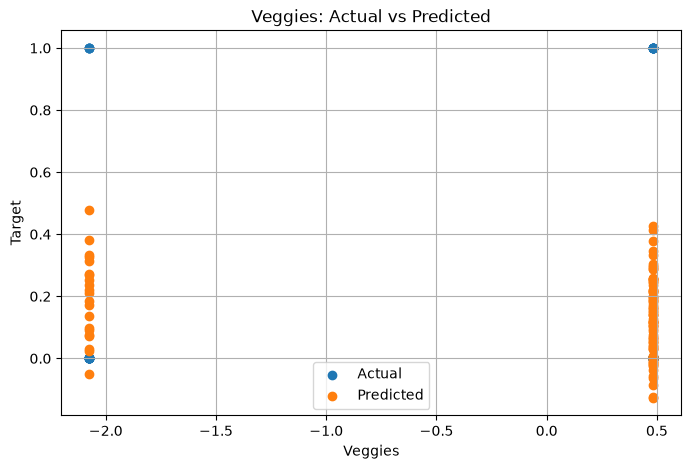

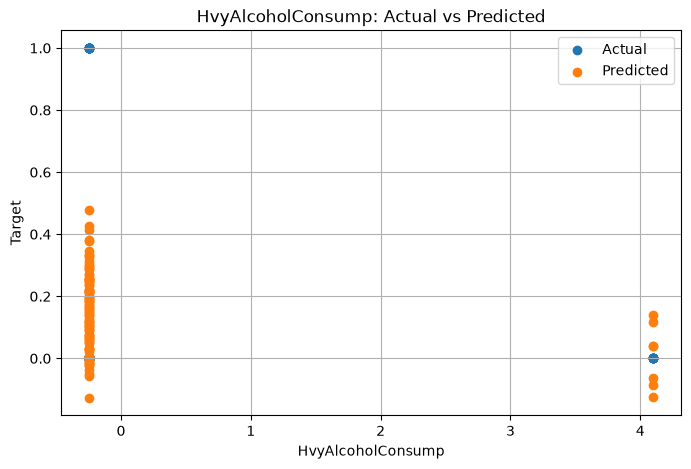

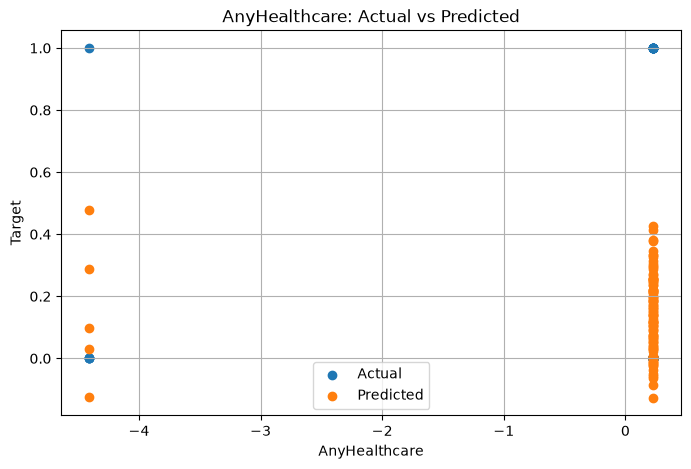

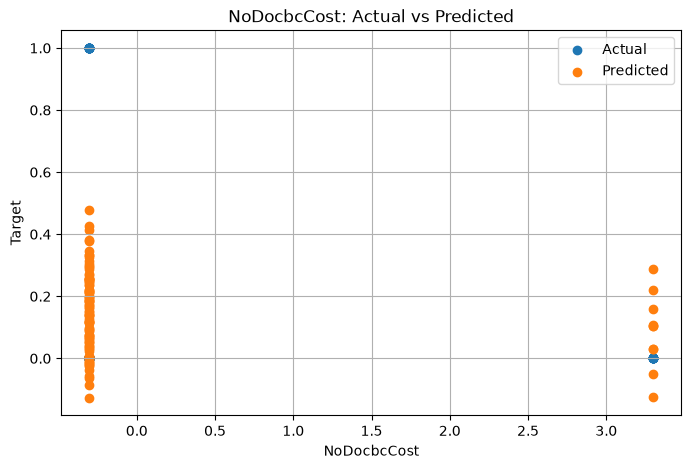

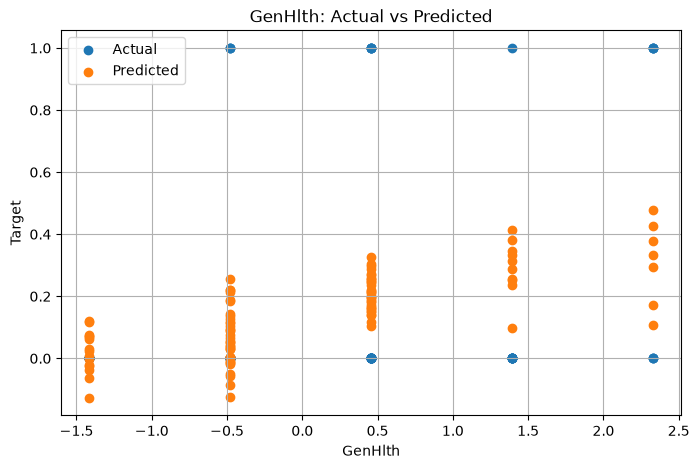

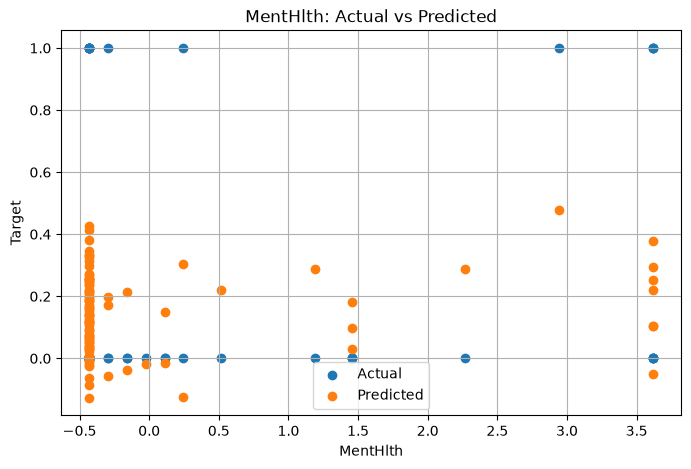

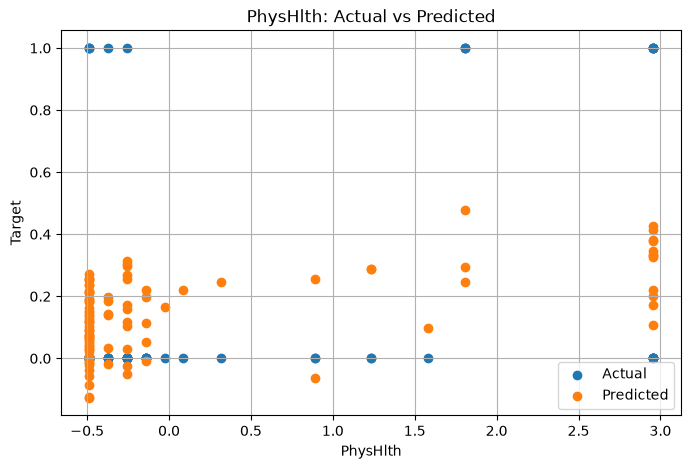

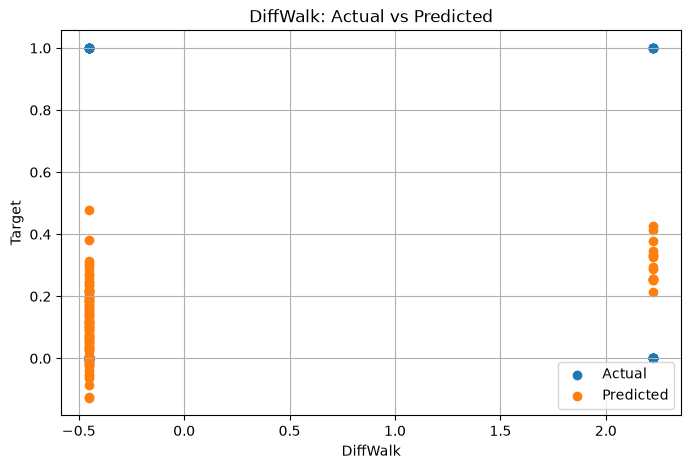

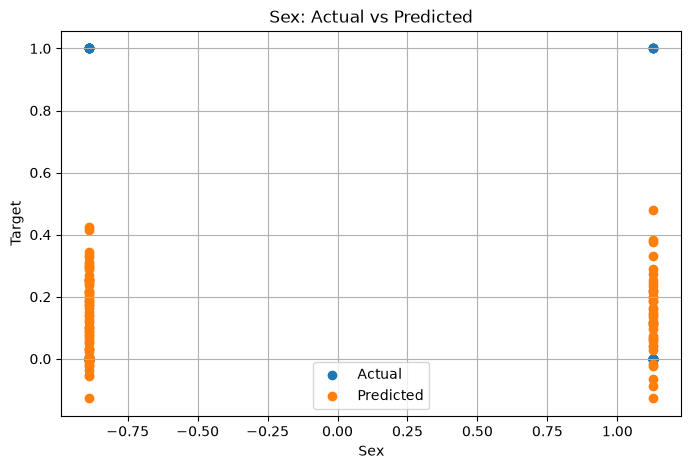

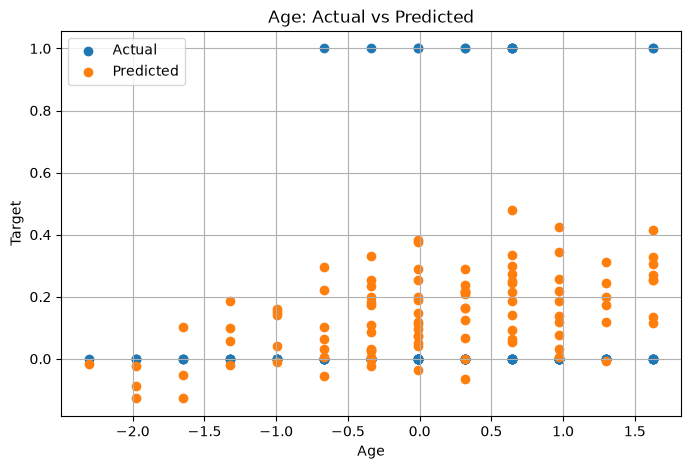

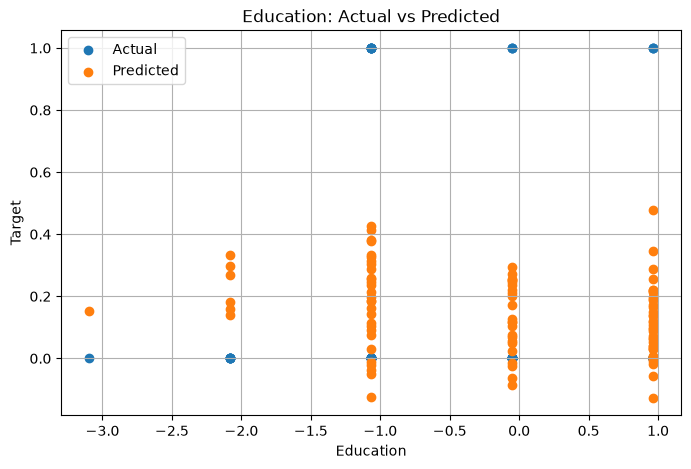

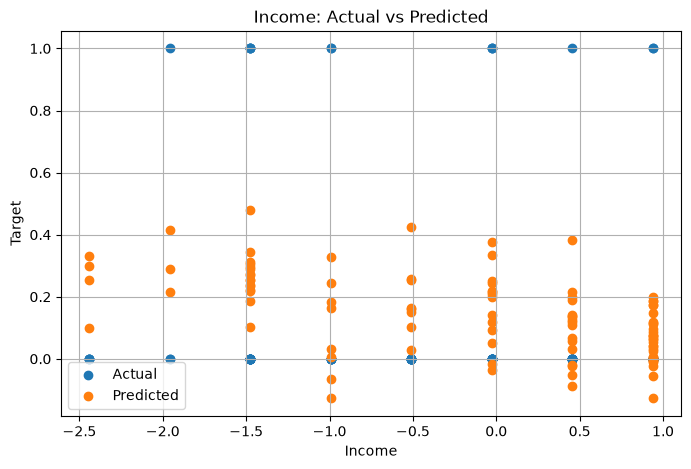

In [6]:
# Ridge regression

SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
df = standardization(df, df.columns)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)

alphas = []

rmse_values = []
alpha = 10**(-20)
for _ in range(50):
    alphas.append(alpha)
    model = sk.linear_model.Ridge(alpha=alpha)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    _, rmse, _ = get_regression_scores(y_test, y_pred)

    rmse_values.append(rmse)
    alpha*= 10
    

plt.plot(alphas, rmse_values, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Ridge Regression: Alpha vs RMSE")
plt.show()

lowest_rmse = min(rmse_values)
ind_lowest_rmse = rmse_values.index(lowest_rmse)
most_accurate_alpha = alphas[ind_lowest_rmse]
print(f"Least RMSE value: {lowest_rmse}")
print(f"Coresponding learning rate: {most_accurate_alpha}")


model = sk.linear_model.Ridge(alpha=most_accurate_alpha)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.show()

r2, rmse, mae = get_regression_scores(y_test,y_pred)
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")
print(f"MAE score: {mae}")


max_points = 100
n_points = min(max_points, len(x_test))

# Randomly select indices
random_indices = np.random.choice(
    len(x_test),
    size=n_points,
    replace=False
)

for feature in x_test.columns:

    plt.figure(figsize=(8, 5))

    x_values = x_test[feature].iloc[random_indices]
    actual = y_test.iloc[random_indices]
    predicted = y_pred[random_indices]

    plt.scatter(x_values, actual, label="Actual")
    plt.scatter(x_values, predicted, label="Predicted")

    plt.xlabel(feature)
    plt.ylabel("Target")
    plt.title(f"{feature}: Actual vs Predicted")

    plt.legend()
    plt.grid(True)
    plt.show()


alpha=1e-05  zero features=0   non-zero features=21
alpha=0.0001 zero features=1   non-zero features=20
alpha=0.001  zero features=2   non-zero features=19
alpha=0.01   zero features=10  non-zero features=11
alpha=0.1    zero features=20  non-zero features=1


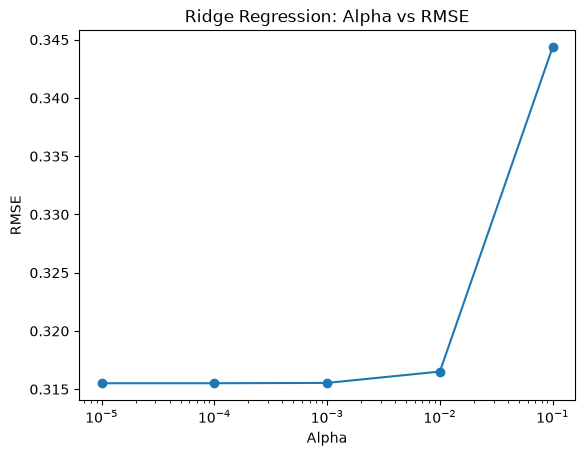

Least RMSE value: 0.3155130135515165
Coresponding learning rate: 1e-05


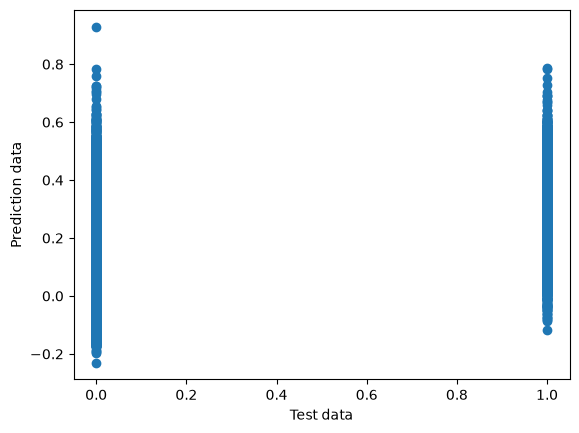

R2 score: 0.16269021365969583
RMSE score: 0.31551297282624857
MAE score: 0.21599714558514607


In [7]:
# Lasso regression

SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
df = standardization(df, df.columns)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)

alphas = []

rmse_values = []


alpha = 10**(-5)
for _ in range(5):
    alphas.append(alpha)
    model = sk.linear_model.Lasso(alpha=alpha)
    model.fit(x_train, y_train)

    zero = (model.coef_ == 0).sum()

    print(
        f"alpha={alpha:<6} "
        f"zero features={zero:<3} "
        f"non-zero features={len(model.coef_) - zero}"
    )

    
    y_pred = model.predict(x_test)

    _, rmse, _ = get_regression_scores(y_test, y_pred)

    rmse_values.append(rmse)


    

    alpha*=10

    
plt.plot(alphas, rmse_values, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Ridge Regression: Alpha vs RMSE")
plt.show()

lowest_rmse = min(rmse_values)
ind_lowest_rmse = rmse_values.index(lowest_rmse)
most_accurate_alpha = alphas[ind_lowest_rmse]
print(f"Least RMSE value: {lowest_rmse}")
print(f"Coresponding learning rate: {most_accurate_alpha}")


model = sk.linear_model.Ridge(alpha=most_accurate_alpha)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.show()

r2, rmse, mae = get_regression_scores(y_test,y_pred)
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")
print(f"MAE score: {mae}")



c:\Users\pavan\sriram\projects\ML-Diabetes-Case-Study\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ElasticNet from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\pavan\sriram\projects\ML-Diabetes-Case-Study\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ElasticNet from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\pavan\sriram\projects\ML-Diabetes-Case-Study\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle 

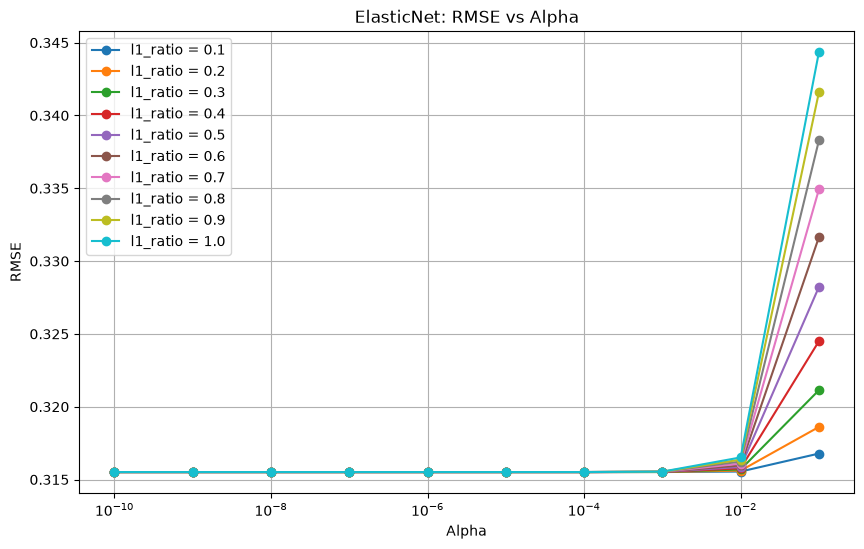

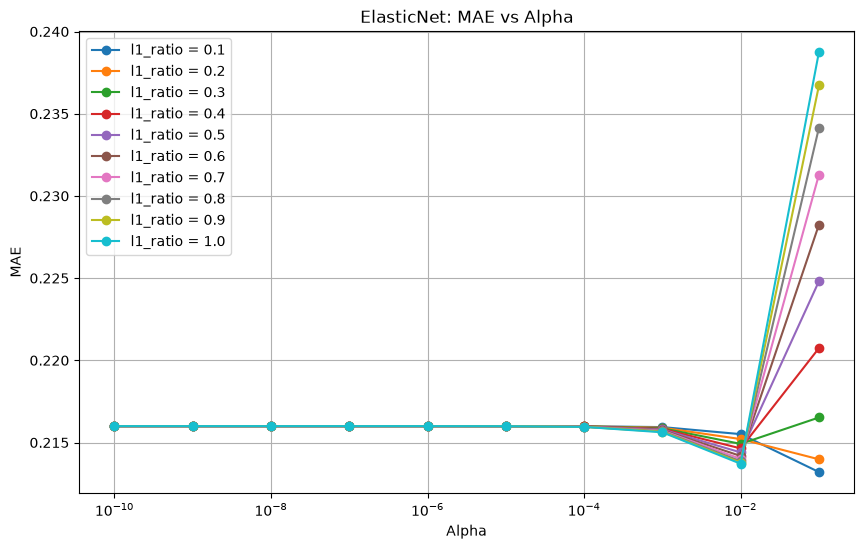

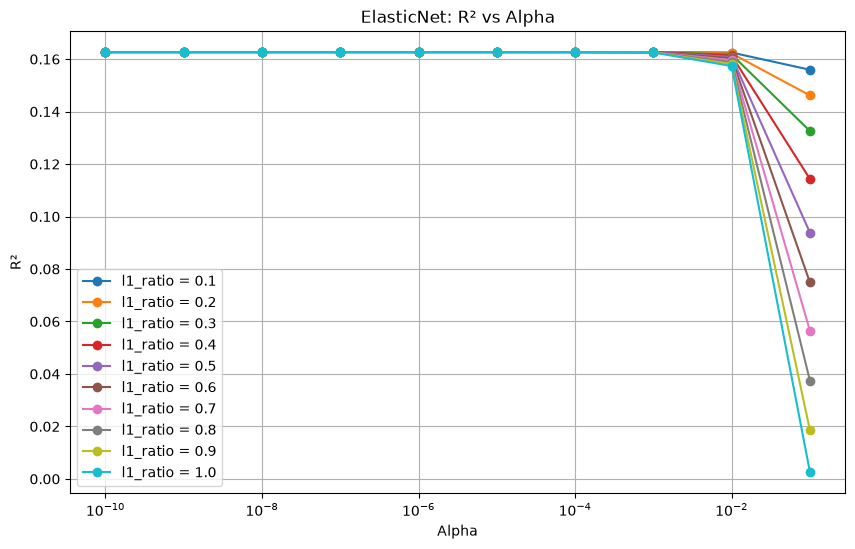

In [8]:
# ElasticNet regression

SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
df = standardization(df, df.columns)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)


results = [] #each element: (l1_ratio, alpha, rmse, mae, r2)
alpha = 10**(-10)
l1_ratio = 0.1

for _ in range(10):
    alpha = 10**(-10)
    for _ in range(10):
        model_path = f"../models/elasticNet_l1_ratio_{l1_ratio}_alpha_{alpha}.pkl"
        if os.path.exists(model_path):
            model = joblib.load(model_path)
        else:
            model = sk.linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio)
            model.fit(x_train,y_train)
            joblib.dump(model, model_path)
        y_pred = model.predict(x_test)
        r2, rmse, mae = get_regression_scores(y_test,y_pred)
        results.append((l1_ratio,alpha, rmse, mae, r2))
        alpha*=10
    l1_ratio+=0.1


results = np.array(results)

l1_ratios = results[:, 0]
alphas = results[:, 1]
rmse = results[:, 2]
mae = results[:, 3]
r2 = results[:, 4]

plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        rmse[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("ElasticNet: RMSE vs Alpha")
plt.legend()
plt.grid(True)

plt.show()

# MAE plot
plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        mae[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("ElasticNet: MAE vs Alpha")
plt.legend()
plt.grid(True)

plt.show()

# R² plot
plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        r2[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("ElasticNet: R² vs Alpha")
plt.legend()
plt.grid(True)

plt.show()




c:\Users\pavan\sriram\projects\ML-Diabetes-Case-Study\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PolynomialFeatures from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\pavan\sriram\projects\ML-Diabetes-Case-Study\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\pavan\sriram\projects\ML-Diabetes-Case-Study\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying 

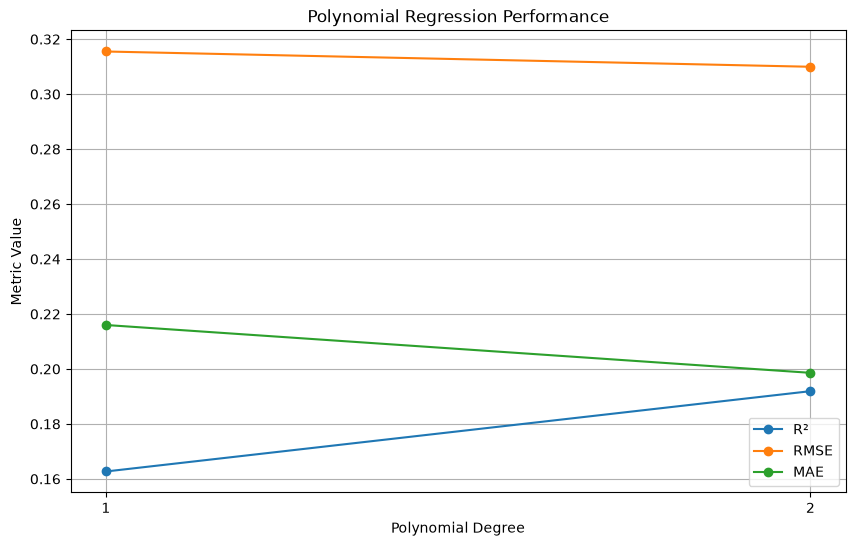

In [9]:
# Polynomial Regression



SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)
degrees = range(1, 3)
results = [] #each element: (degree, r2,rmse,mae)
for degree in degrees:
    model_path = f"../models/poly_regression_degree_{degree}.pkl"
    if os.path.exists(model_path):
        poly, scaler, model = joblib.load(model_path)
    else:
        poly = sk.preprocessing.PolynomialFeatures(degree=degree)
        poly.fit(x_train)
        scaler = sk.preprocessing.StandardScaler()
        model = sk.linear_model.LinearRegression()
        x_train_poly = poly.transform(x_train)
        x_test_poly = poly.transform(x_test)
        scaler.fit(x_train_poly)
        x_train_scaled = scaler.transform(x_train_poly)
        x_test_scaled = scaler.transform(x_test_poly)
        model.fit(x_train_scaled,y_train)
        joblib.dump((poly, scaler, model),model_path)
    
    
    
    x_test_poly = poly.transform(x_test)
    x_test_scaled = scaler.transform(x_test_poly)
    
    y_pred = model.predict(x_test_scaled)
    
    rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred))
    mae = sk.metrics.mean_absolute_error(y_test, y_pred)
    r2 = sk.metrics.r2_score(y_test, y_pred)

    results.append((degree, r2, rmse, mae))

results = np.array(results)

degrees_plot = results[:, 0]
r2 = results[:, 1]
rmse = results[:, 2]
mae = results[:, 3]

plt.figure(figsize=(10, 6))

plt.plot(degrees_plot, r2, marker="o", label="R²")
plt.plot(degrees_plot, rmse, marker="o", label="RMSE")
plt.plot(degrees_plot, mae, marker="o", label="MAE")

plt.xlabel("Polynomial Degree")
plt.ylabel("Metric Value")
plt.title("Polynomial Regression Performance")
plt.xticks(degrees_plot)
plt.legend()
plt.grid(True)
plt.show()